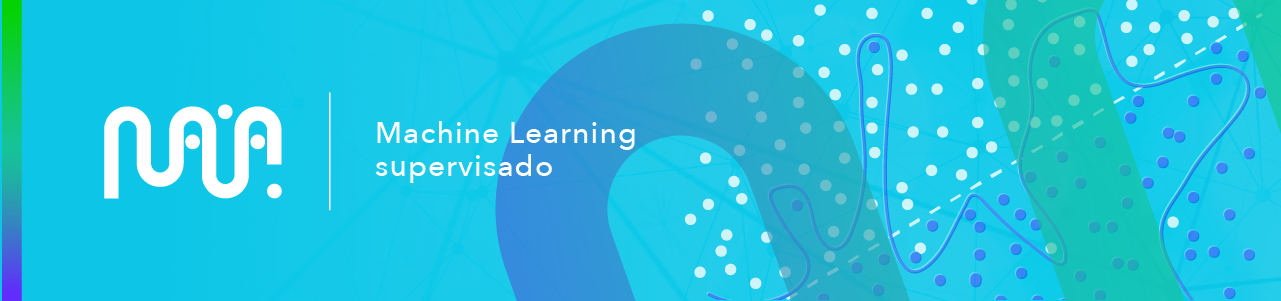
# Taller 4. Selección de modelos
***MLS. Machine learning supervisado***
<br>***Semana 4, Taller:*** *Selección de modelo y regularización*
<br> **Profesor:** *Fernando Lozano* - **Autor Notebook:** *Mónica Gantiva*



## Introducción
### Descripción
Este *jupyter notebook* contiene el material necesario para el desarrollo del Taller calificable de la Semana 4 del curso *MLS: Machine learning supervisado*. En esta tarea usted deberá solucionar un problema de clasificación binaria aplicando varios modelos y seleccionando el más conveniente.

#### Objetivos de Aprendizaje
<br>Identificar overfitting y underfitting en un modelo de aprendizaje supervisado. 
<br>Seleccionar apropiadamente la complejidad de un modelo en aprendizaje supervisado. 


### Metodología
En este taller se abordará un poblema aplicado de clasificación binaria para el cual usted deberá tomar dos modelos de machine learning propuestos y mejorar su desempeño. Para ello emplee las celdas que tienen la siguiente notación.

In [ ]:
# =====================================================
# COMPLETAR ===========================================
# 

# =====================================================

Así mismo, usted deberá análizar los resultados obtenidos para cada modelo. Para ello, responda las preguntas que se presentarán durante el taller. Dispondra de celdas con la siguiente notación para escribir su análisis:

***Respuesta:***

### Problema aplicado: clasificación de reservas de un hotel


En la industria hotelera es deseable estimar si un cliente cumplirá con la reservación previamente hecha. En este caso, se tiene una base de datos con la información del comportamiento de clientes que han realizado reservaciones en un hotel y el cumplimiento o cancelación de dicha reserva. En esta actividad se implementarán árboles de decisión y random forest para  predecir si un cliente cancelará o no su reserva y clasificar el estado de su reserva según el comportamiento que presente. La base de datos usada ha sido tomada de [1]
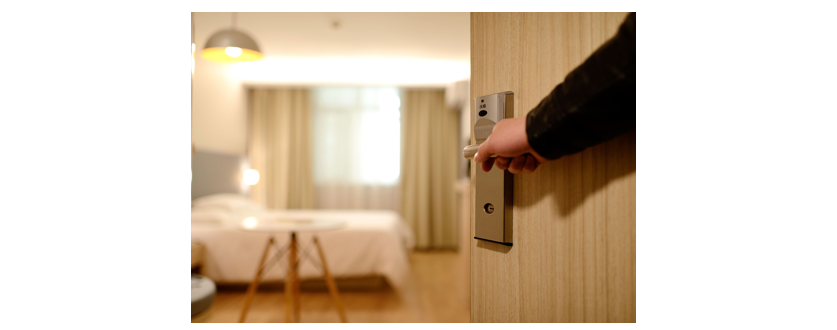

 Imagen tomada de [2]


***referencias***
<br>[1]https://www.kaggle.com/datasets/gauravduttakiit/reservation-cancellation-prediction
<br>[2]https://pixabay.com/es/photos/hotel-habitaci%C3%B3n-nuevo-producto-1330850/

#### Inicialización


In [2]:
import numpy as np 
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn import tree
import seaborn as sns

#### Cargamos los datos

In [3]:
datos_train = pd.read_csv('train.csv')
datos_train.head()

,id,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,0,2,0,0,2,1,0,0,9,2018,1,14,1,1,11,0,67.50,0,0
1,1,2,0,1,2,0,0,0,117,2018,7,29,0,0,0,0,72.25,0,0
2,2,2,0,0,1,0,0,0,315,2018,12,2,0,0,0,0,52.00,0,0
3,3,1,0,0,2,1,0,0,32,2018,12,1,1,0,0,0,56.00,0,0
4,4,2,0,1,0,0,0,0,258,2018,10,16,0,0,0,0,100.00,0,1


Podemos ver que el archivo contiene los diferentes atributos de los detalles de la reserva de los clientes. El diccionario de datos detallado se proporciona a continuación.

* no_of_adults: Número de adultos
* no_of_children Número de niños
* no_of_weekend_nights: Número de noches de fin de semana (sábado o domingo) que el huésped se hospedó o reservó para quedarse en el hotel
* no_of_week_nights: Número de noches de la semana (lunes a viernes) que el huésped se hospedó o reservó para quedarse en el hotel
* type_of_meal_plan: Tipo de plan de comidas reservado por el cliente:
* required_car_parking_space: ¿Necesita el cliente una plaza de aparcamiento? (0 - No, 1 - Sí)
* room_type_reservated: Tipo de habitación reservada por el cliente. Los valores son cifrados (codificados) por INN Hotels.
* lead_time: Número de días entre la fecha de reserva y la fecha de llegada
* arrival_year: año de la fecha de llegada
* arrival_month: Mes de la fecha de llegada
* arrival_date: Fecha del mes
* market_segment_type: Designación del segmento de mercado.
* repeated_guest: ¿El cliente es un invitado repetido? (0 - No, 1 - Sí)
* no_of_previous_cancellations: número de reservas anteriores que fueron canceladas por el cliente antes de la reserva actual
* no_of_previous_bookings_not_canceled: Número de reservas anteriores no canceladas por el cliente antes de la reserva actual
* avg_price_per_room: Precio medio por día de la reserva; Los precios de las habitaciones son dinámicos. (en euros)
* no_of_special_requests: número total de solicitudes especiales realizadas por el cliente (por ejemplo, piso alto, vista desde la habitación, etc.)
* booking_status: Bandera que indica si la reserva fue cancelada o no.

La última columna corresponde al estado de la reserva, siendo 0 para cancelado y 1 para cumplimiento de la reserva. Esta es nuestra variable objetivo. Procedemos a separar las variables de predicción y la objetivo y los conjuntos de entrenamiento y prueba

#### Separación de datos
Ahora se tomarán los datos correspondientes a las variables independiente y dependientes. Así mismo, se realiza la separa de los datos en el conjunto de entrenamiento y prueba

In [4]:
X_train = datos_train.drop('booking_status',axis=1)
y_train =datos_train['booking_status']

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.25, random_state=42)

### Modelo 1: Arbol de decisión
Ahora se muestra un ejemplo de cómo aplicar un modelo de árbol de decisión para realizar la clasificación deseada. Observe que se crea el modelo, se hace el entrenamiento y se evalúa el desempeño del modelo para el conjunto de entrenamiento y prueba. Por último, se obtiene la matríz de confusión del modelo.


El accuracy de entrenamiento es: 1.0
El accuracy prueba es: 0.7496437054631829


Text(50.722222222222214, 0.5, 'Verdad')

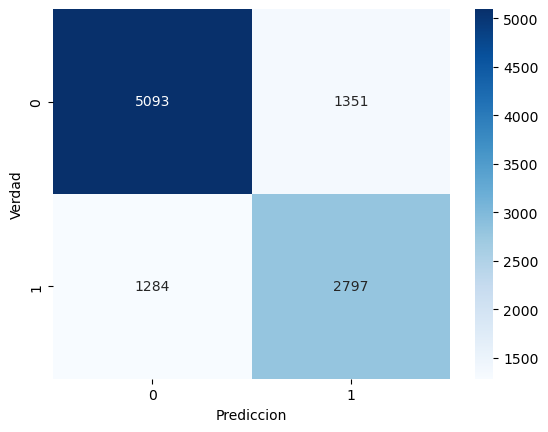

In [5]:
#creación del modelo
d_tree=DecisionTreeClassifier(max_depth=40)

#Entrenamiento del modelo
d_tree.fit(X_train, y_train)

#Predicción de los datos de entrenamiento
y_pred_train=d_tree.predict(X_train)

#Métricas de desempeño 
accuaracy_train=accuracy_score(y_train, y_pred_train)
print (f"El accuracy de entrenamiento es: {accuaracy_train}")

#Predicción de los datos de prueba
y_pred_ds=d_tree.predict(X_test)

#Métricas de desempeño 
accuaracy_ds=accuracy_score(y_test, y_pred_ds)
print (f"El accuracy prueba es: {accuaracy_ds}")

sns.heatmap(confusion_matrix(y_test, y_pred_ds),annot=True,fmt='g',cmap='Blues')
plt.xlabel('Prediccion')
plt.ylabel('Verdad')

Tomando como guía el ejemplo anterior, modifique parámetros como la profundidad del árbol de decisión. Varíe este parámetro al menos 4 veces entre los valores de 1 a 40. Para este punto debe mostrar el desempeño para cada caso. Tengan en cuenta como cambia el accuracy de entrenamiento y prueba para cada caso y el comportamiento de la matriz confusión. 

Profundidad del árbol: 5
Accuracy entrenamiento: 0.796
Accuracy prueba: 0.796


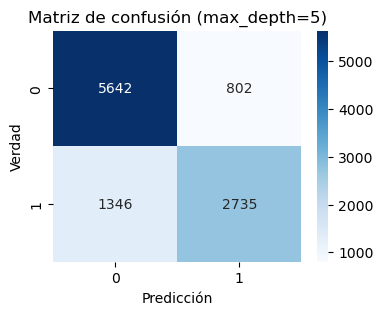

Profundidad del árbol: 10
Accuracy entrenamiento: 0.830
Accuracy prueba: 0.804


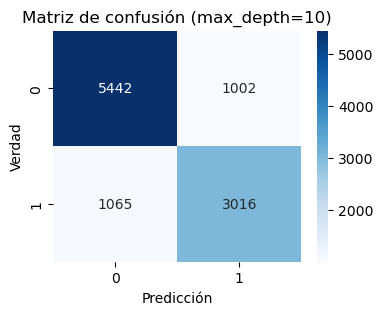

Profundidad del árbol: 20
Accuracy entrenamiento: 0.955
Accuracy prueba: 0.763


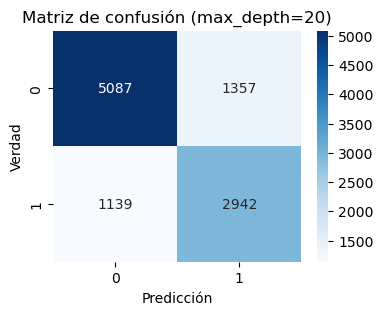

Profundidad del árbol: 30
Accuracy entrenamiento: 0.996
Accuracy prueba: 0.748


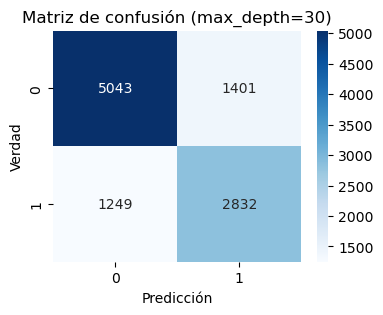

In [15]:
# =====================================================
# COMPLETAR ===========================================
# 
# Profundidades del árbol de decisión
depth_values = [5, 10, 20, 30]

# Lista para guardar resultados
results = []

# Iteración sobre cada profundidad
for depth in depth_values:
    # Creación del modelo
    d_tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    d_tree.fit(X_train, y_train)

    # Predicciones
    y_pred_train = d_tree.predict(X_train)
    y_pred_test = d_tree.predict(X_test)

    # Métricas
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)

    # Guardar resultados en lista
    results.append({
        "depth": depth,
        "acc_train": acc_train,
        "acc_test": acc_test,
        "conf_matrix": confusion_matrix(y_test, y_pred_test)
    })

# Mostrar resultados
for res in results:
    print(f"Profundidad del árbol: {res['depth']}")
    print(f"Accuracy entrenamiento: {res['acc_train']:.3f}")
    print(f"Accuracy prueba: {res['acc_test']:.3f}")
    
    plt.figure(figsize=(4,3))
    sns.heatmap(res["conf_matrix"], annot=True, fmt='g', cmap='Blues')
    plt.title(f"Matriz de confusión (max_depth={res['depth']})")
    plt.xlabel('Predicción')
    plt.ylabel('Verdad')
    plt.show()
    
# =====================================================

Responda la siguientes preguntas:
1. ¿Cómo afecta la variación de estos parámetros en el desempeño del modelo? Justifique su respuesta
2. ¿Observa sobreajuste en algunos de los modelos? Justifique su respuesta
3. De las variaciones que aplicó el modelo de Arbol de desición ¿Cuál fué el modelo con mejor desempeño?

***RESPUESTAS***

1. Al aumentar la profundida del arbol, el modelo gana mas capacidad para poder aprender los patrones mas complejos en los datos, pero esto tambien hace que se incremente el riesgo de sobreaste en el modelo ya que puede estar memorizando los datos de entrenamiento y pierde asi su capacidad de generalizacion. esto se puede visualizar con el acurracy de entrenamiento y prueba mientras que para una profundida de 5 a 10 se mantiene estable ambos para profundidades mas altas el acurracy de prueba baja

2. Si se observa sobreajuste en los modelos, principalmente en arboles de decision con profundidades altas como 20 o 30, pues para los datos de entrenamiento se cuenta con un buen accuracy es decir entiende y comprende muy bien los datos de entrenamiento, provoca igual que en su prueba su desemnpeño sea deficiente vs el de entrenamiento, lo que da un claro ejemplo de sobreajuste a los datos de entrenamiento

3. El mejor modelo que se logra evidenciar con un buen balance entre ambos accuracy es el modelo con una profundidad de 10, donde ambos accuracy estan aprox 80% pues logra aprender bien los patrones de entrenamiento y logra asi generalizar con datos nuevos o de prueba

### Modelo 2: Regresión logística

Ahora se muestra un ejemplo de cómo aplicar un modelo de regresión logística para realizar la clasificación deseada. Observe que se crea el modelo, se hace el entrenamiento y se evalúa el desempeño del modelo para el conjunto de entrenamiento y prueba. Por último, se obtiene la matríz de confusión del modelo.

El accuracy de entrenamiento es: 0.7263974663499604
El accuracy de prueba es: 0.7307363420427554


Text(50.722222222222214, 0.5, 'Verdad')

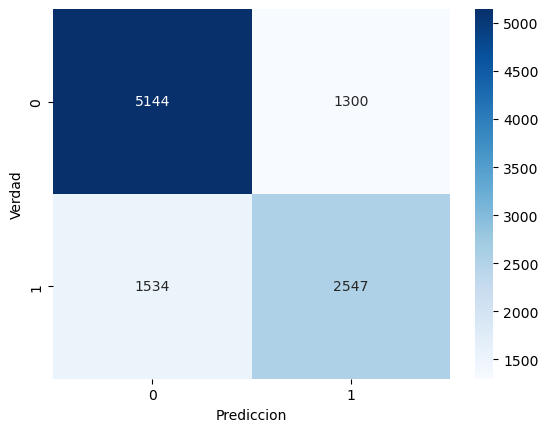

In [16]:

# Crear el modelo
model = LogisticRegression()

#Entrenamiento del modelo
model.fit(X_train, y_train)

#Predicción de los datos de entrenamiento
y_pred_train=model.predict(X_train)

#Métricas de desempeño 
accuaracy_train=accuracy_score(y_train, y_pred_train)
print (f"El accuracy de entrenamiento es: {accuaracy_train}")


#Predicción de los datos de prueba
y_pred_ds=model.predict(X_test)

#Métricas de desempeño
accuaracy_prueba=accuracy_score(y_test, y_pred_ds)
print (f"El accuracy de prueba es: {accuaracy_prueba}")

sns.heatmap(confusion_matrix(y_test, y_pred_ds),annot=True,fmt='g',cmap='Blues')
plt.xlabel('Prediccion')
plt.ylabel('Verdad')

Tomando como guía el ejemplo anterior, aplique el parámetro de regularización C al modelo de regresión lodística. Varíe este parámetro al menos 4 veces entre los valores de 0.01 a 100. Para este punto debe mostrar el desempeño para cada caso. Tengan en cuenta como cambia el accuracy de entrenamiento y prueba para cada caso y el comportamiento de la matriz confusión. 

In [ ]:
# =====================================================
# COMPLETAR ===========================================
# 

# =====================================================

Valor de C: 0.01
Accuracy entrenamiento: 0.721
Accuracy prueba: 0.728


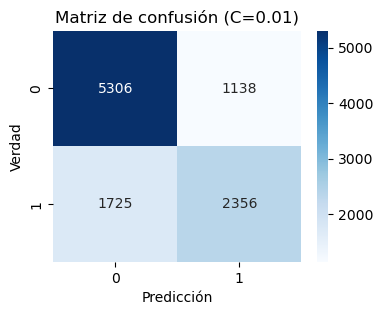

Valor de C: 0.1
Accuracy entrenamiento: 0.721
Accuracy prueba: 0.728


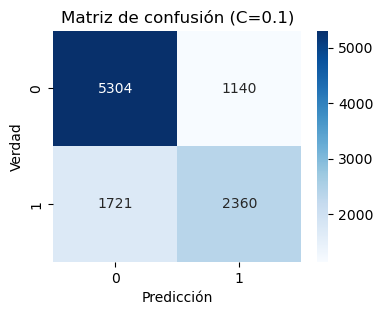

Valor de C: 1
Accuracy entrenamiento: 0.726
Accuracy prueba: 0.731


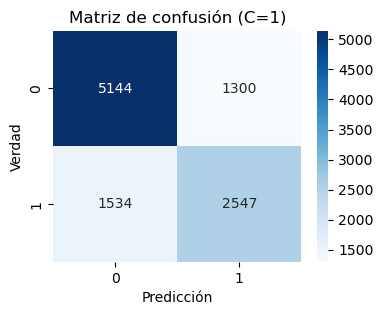

Valor de C: 10
Accuracy entrenamiento: 0.737
Accuracy prueba: 0.741


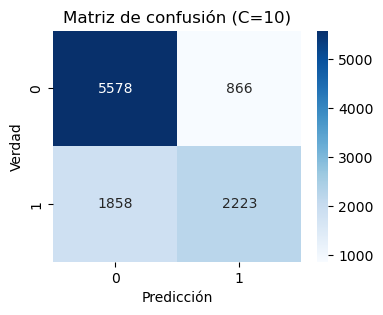

Valor de C: 100
Accuracy entrenamiento: 0.722
Accuracy prueba: 0.728


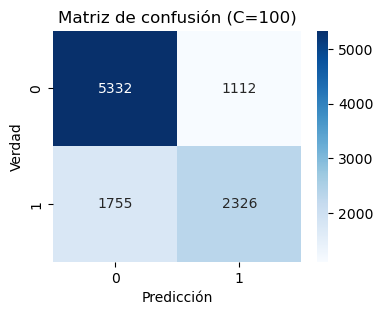

In [18]:
# Valores de C a probar
C_values = [0.01, 0.1, 1, 10, 100]

# Lista para guardar resultados
results = []

for c in C_values:
    # Crear modelo con regularización C
    model = LogisticRegression(C=c, random_state=42)
    model.fit(X_train, y_train)
    
    # Predicciones
    y_pred_train = model.predict(X_train)
    y_pred_test = model.predict(X_test)
    
    # Métricas
    acc_train = accuracy_score(y_train, y_pred_train)
    acc_test = accuracy_score(y_test, y_pred_test)
    
    # Guardar resultados
    results.append({
        "C": c,
        "acc_train": acc_train,
        "acc_test": acc_test,
        "conf_matrix": confusion_matrix(y_test, y_pred_test)
    })

# Mostrar resultados
for res in results:
    print(f"Valor de C: {res['C']}")
    print(f"Accuracy entrenamiento: {res['acc_train']:.3f}")
    print(f"Accuracy prueba: {res['acc_test']:.3f}")
    
    plt.figure(figsize=(4,3))
    sns.heatmap(res["conf_matrix"], annot=True, fmt='g', cmap='Blues')
    plt.title(f"Matriz de confusión (C={res['C']})")
    plt.xlabel('Predicción')
    plt.ylabel('Verdad')
    plt.show()


Responda la siguientes preguntas:

1. ¿Cómo afecta la variación de estos parámetros en el desempeño del modelo? Justifique su respuesta
2. ¿Observa sobreajuste en algunos de los modelos? Justifique su respuesta
3. Teniendo en cuenta los modelos de árbol de desición y regresión logística ¿Cuál fué el modelo con mejor desempeño?Justifique su respuesta
4. ¿De que otra manera cree que podría mejorar el desempeño de cada uno de los modelos trabajados durante este taller?

***RESPUESTAS***

1. Al variar el parámetro de regularización C en la regresión logística se observa que valores muy pequeños (0.01 y 0.1) generan un modelo más simple con accuracies moderados, mientras que valores intermedios como 1 y 10 logran un mejor equilibrio y alcanzan los mayores desempeños tanto en entrenamiento como en prueba; en cambio, valores muy grandes como 100 no aportan mejoras y el desempeño incluso disminuye ligeramente, lo que muestra que la regularización adecuada ayuda a controlar el sesgo y la varianza del modelo.

2. No se evidencia un sobreajuste marcado ya que los accuracies de entrenamiento y prueba se mantienen muy similares en todos los casos, mientras que en los árboles de decisión sí se observa sobreajuste en profundidades altas (20 y 30), donde el modelo memoriza los datos de entrenamiento y pierde capacidad de generalización en la prueba.

3. Comparando ambos modelos, el mejor desempeño se logra con el árbol de decisión con profundidad 10, que alcanza un accuracy de entrenamiento de 0.830 y de prueba de 0.804, mostrando un buen balance entre aprender patrones y generalizar con datos nuevos; la regresión logística con C=10 también es estable pero con menor precisión global.

4. El desempeño de ambos modelos podría mejorarse aplicando técnicas como poda y ajuste de hiperparámetros en los árboles de decisión, o probando diferentes tipos de regularización y escalado de variables en la regresión logística; además, el uso de validación cruzada, balanceo de clases y métodos ensemble como Random Forest o Gradient Boosting permitiría obtener modelos más robustos y con mejor capacidad de generalización.